# Exercise 4: Forecast diabetes progression

??? audit ????? ????? ?????? ?????. ? ????? ??????? `scikit-learn` ????????? `load_diabetes()` ???? ????????? ????????? ????? ???????????? `0.22`, ??????? ???????????? ????? ???????? ?????????? ??????????? legacy-????? ????????, ??????????? ? `data/legacy`.

?????? ??? ???? ????????? ??????? `LinearRegression` ?? ???????? `scikit-learn`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid")

def locate_project_root():
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidate in candidates:
        if (candidate / "data" / "legacy" / "diabetes_data.csv.gz").exists():
            return candidate
    raise FileNotFoundError("Could not find data/legacy from the current notebook location.")

def compute_mse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return np.mean((y_true - y_pred) ** 2)

project_root = locate_project_root()
feature_names = ["age", "sex", "bmi", "bp", "s1", "s2", "s3", "s4", "s5", "s6"]

X = pd.DataFrame(
    np.loadtxt(project_root / "data" / "legacy" / "diabetes_data.csv.gz"),
    columns=feature_names,
)
y = pd.Series(
    np.loadtxt(project_root / "data" / "legacy" / "diabetes_target.csv.gz"),
    name="target",
)


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=43,
)

print(y_train.values[:10])
print(y_test.values[:10])


[202.  55. 202.  42. 214. 173. 118.  90. 129. 151.]
[ 71.  72. 235. 277. 109.  61. 109.  78.  66. 192.]


In [3]:
model = LinearRegression().fit(X_train, y_train)

audit_coefficients_and_intercept = [
    ("age", -60.40163046086952),
    ("sex", -226.08740652083418),
    ("bmi", 529.383623302316),
    ("bp", 259.96307686274605),
    ("s1", -859.121931974365),
    ("s2", 504.70960058378813),
    ("s3", 157.42034928335502),
    ("s4", 226.29533600601638),
    ("s5", 840.7938070846119),
    ("s6", 34.712225788519554),
    ("intercept", 152.05314895029233),
]

for (name, expected), actual in zip(audit_coefficients_and_intercept[:-1], model.coef_):
    assert np.isclose(actual, expected, atol=1e-9), f"{name}: {actual} != {expected}"
assert np.isclose(model.intercept_, audit_coefficients_and_intercept[-1][1], atol=1e-9)

print(audit_coefficients_and_intercept)


[('age', -60.40163046086952), ('sex', -226.08740652083418), ('bmi', 529.383623302316), ('bp', 259.96307686274605), ('s1', -859.121931974365), ('s2', 504.70960058378813), ('s3', 157.42034928335502), ('s4', 226.29533600601638), ('s5', 840.7938070846119), ('s6', 34.712225788519554), ('intercept', 152.05314895029233)]


In [4]:
predictions_on_train = model.predict(X_train).reshape(-1, 1)
predictions_on_test = model.predict(X_test).reshape(-1, 1)

train_mse = compute_mse(y_train, predictions_on_train)
test_mse = compute_mse(y_test, predictions_on_test)

print(repr(predictions_on_test[:10]))
print(f"Train MSE: {train_mse:.6f}")
print(f"Test MSE: {test_mse:.6f}")


array([[111.74351759],
       [ 98.41335251],
       [168.36373195],
       [255.05882934],
       [168.43764643],
       [117.60982186],
       [198.86966323],
       [126.28961941],
       [117.73121787],
       [224.83346984]])
Train MSE: 2888.326888
Test MSE: 2858.255153


?? ??????? `y_true vs y_pred` ?????? ?????, ??? ?????? ? ??????? ????? ????? ?????, ?? ??????? ???????? ?????????? ????????????? ? ???????? ?????????.


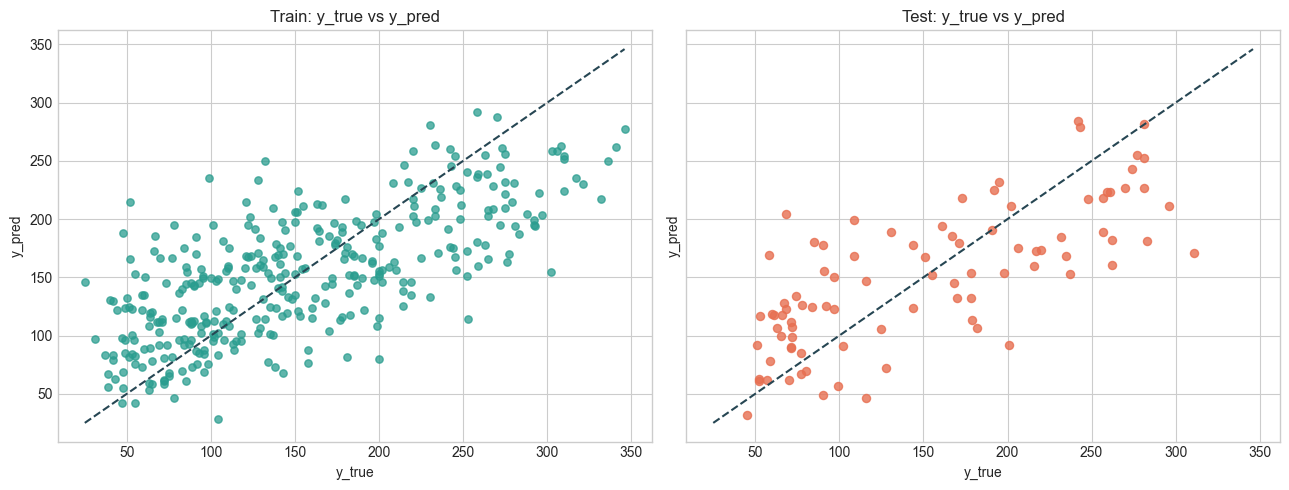

In [5]:
train_pred = predictions_on_train.ravel()
test_pred = predictions_on_test.ravel()
diagonal_min = min(y_train.min(), y_test.min(), train_pred.min(), test_pred.min())
diagonal_max = max(y_train.max(), y_test.max(), train_pred.max(), test_pred.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

axes[0].scatter(y_train, train_pred, s=28, color="#2a9d8f", alpha=0.75)
axes[0].plot([diagonal_min, diagonal_max], [diagonal_min, diagonal_max], color="#264653", linestyle="--")
axes[0].set(title="Train: y_true vs y_pred", xlabel="y_true", ylabel="y_pred")

axes[1].scatter(y_test, test_pred, s=34, color="#e76f51", alpha=0.8)
axes[1].plot([diagonal_min, diagonal_max], [diagonal_min, diagonal_max], color="#264653", linestyle="--")
axes[1].set(title="Test: y_true vs y_pred", xlabel="y_true", ylabel="y_pred")

fig.tight_layout()
plt.show()


??????? ?????? ?????????? ?????? ???? ??? ??????????? ??????. ?? test-?????? ??????? ???????? ????, ??? ?? train.


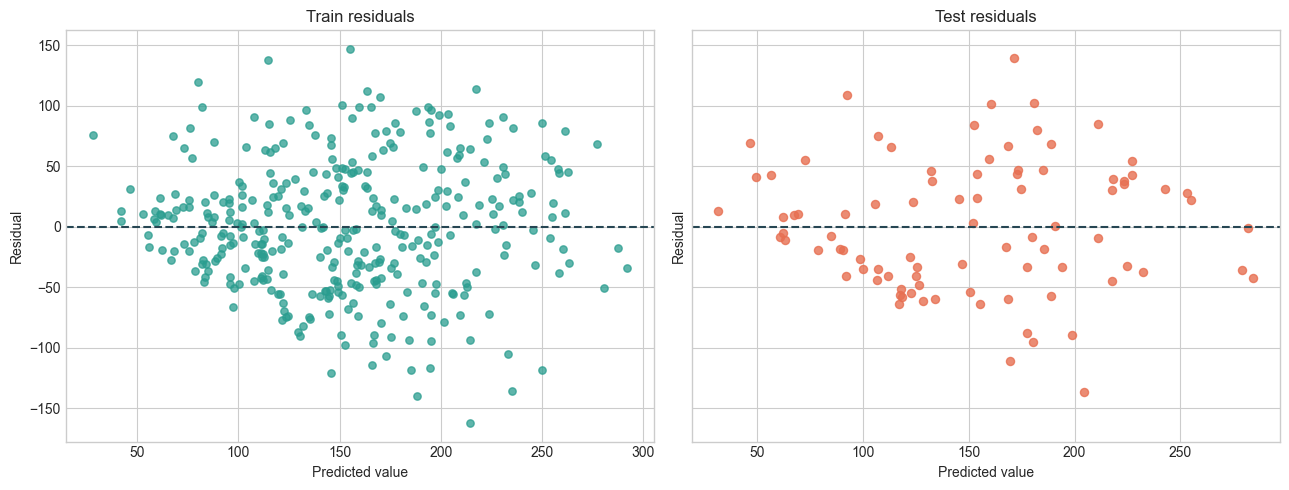

In [6]:
train_residuals = y_train.to_numpy() - train_pred
test_residuals = y_test.to_numpy() - test_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

axes[0].scatter(train_pred, train_residuals, s=28, color="#2a9d8f", alpha=0.75)
axes[0].axhline(0.0, color="#264653", linestyle="--")
axes[0].set(title="Train residuals", xlabel="Predicted value", ylabel="Residual")

axes[1].scatter(test_pred, test_residuals, s=34, color="#e76f51", alpha=0.8)
axes[1].axhline(0.0, color="#264653", linestyle="--")
axes[1].set(title="Test residuals", xlabel="Predicted value", ylabel="Residual")

fig.tight_layout()
plt.show()


???????? ?????????? ????????: ???? ????????? ? ??????? `load_diabetes(as_frame=True)`. ??? ??????????, ??? ??????????? ?????? legacy-?????? ?? ???? ????????? ????, ? ???? ??????????? ?????????? ? audit-?????????? 01-edu.


In [7]:
modern_diabetes = load_diabetes(as_frame=True)
modern_X, modern_y = modern_diabetes.data, modern_diabetes.target
modern_X_train, modern_X_test, modern_y_train, modern_y_test = train_test_split(
    modern_X,
    modern_y,
    test_size=0.2,
    random_state=43,
)
modern_model = LinearRegression().fit(modern_X_train, modern_y_train)

comparison = pd.DataFrame(
    {
        "legacy_audit": model.coef_,
        "modern_loader": modern_model.coef_,
        "abs_diff": np.abs(model.coef_ - modern_model.coef_),
    },
    index=feature_names,
)
comparison.loc["intercept"] = [model.intercept_, modern_model.intercept_, abs(model.intercept_ - modern_model.intercept_)]
comparison.round(6)


,legacy_audit,modern_loader,abs_diff
age,-60.401630,-60.399848,0.001782
sex,-226.087407,-226.083590,0.003816
bmi,529.383623,529.384957,0.001334
bp,259.963077,259.961994,0.001083
s1,-859.121932,-859.093009,0.028923
s2,504.709601,504.686973,0.022627
s3,157.420349,157.410858,0.009491
s4,226.295336,226.293134,0.002202
s5,840.793807,840.784041,0.009766
s6,34.712226,34.712266,0.000040
